# Random Forest

## Importar Dados

In [11]:
import pandas as pd
caminho = '../'

X_test = pd.read_csv(caminho + 'database/processed/splitted/X_test.csv')
X_train = pd.read_csv(caminho + 'database/processed/splitted/X_train.csv')
y_test = pd.read_csv(caminho + 'database/processed/splitted/y_test.csv')
y_train = pd.read_csv(caminho + 'database/processed/splitted/y_train.csv')

## RF - Default

In [12]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(n_estimators=100, random_state=14)
random_forest.fit(X_train, y_train)

c:\Users\renan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


=== MÉTRICAS DE DESEMPENHO (KNN DEFAULT) ===

Acurácia: 0.7928
Precisão: 0.7751
Recall: 0.7311
F1-Score: 0.7451
MCC: 0.5043
AUC: 0.8469
--------------------------------------------------


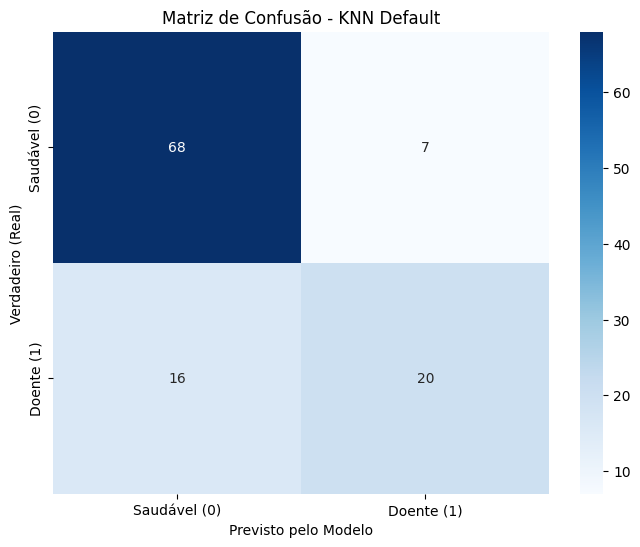

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             matthews_corrcoef, confusion_matrix)

# Fazendo as Previsões no conjunto de teste
y_pred_def = random_forest.predict(X_test)
y_prob_def = random_forest.predict_proba(X_test)[:, 1]

# Métricas
acuracia_def = accuracy_score(y_test, y_pred_def)
precisao_def = precision_score(y_test, y_pred_def, average='macro', zero_division=0)
recall_def = recall_score(y_test, y_pred_def, average='macro', zero_division=0)
f1_def = f1_score(y_test, y_pred_def, average='macro', zero_division=0)
mcc_def = matthews_corrcoef(y_test, y_pred_def)
auc = roc_auc_score(y_test, y_prob_def)

# Exibindo os Resultados
print("=== MÉTRICAS DE DESEMPENHO (KNN DEFAULT) ===\n")
print(f"Acurácia: {acuracia_def:.4f}")
print(f"Precisão: {precisao_def:.4f}")
print(f"Recall: {recall_def:.4f}")
print(f"F1-Score: {f1_def:.4f}")
print(f"MCC: {mcc_def:.4f}")
print(f"AUC: {auc:.4f}")
print("-" * 50)

# Plotando a Matriz de Confusão
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_def)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Saudável (0)', 'Doente (1)'],
            yticklabels=['Saudável (0)', 'Doente (1)'])
plt.title('Matriz de Confusão - KNN Default')
plt.xlabel('Previsto pelo Modelo')
plt.ylabel('Verdadeiro (Real)')
plt.show()

## RF - Melhorado

In [14]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

def objective(trial):
    # Hiperparâmetros
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy'])
    }

    clf = RandomForestClassifier(**params, random_state=14)

    score = cross_val_score(clf, X_train, y_train.values.ravel(), scoring='accuracy', n_jobs=-1, cv=5).mean()
    return score

# Criando e executando
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"Melhor pontuação: {study.best_value:.4f}")
print("Melhores parâmetros:")
print(study.best_params)

# Treinando o modelo final com os melhores parâmetros encontrados
best_rf = RandomForestClassifier(**study.best_params, random_state=14)
best_rf.fit(X_train, y_train.values.ravel())

[I 2026-08-16 11:30:43,350] A new study created in memory with name: no-name-50be4d5e-40bb-487b-9cc0-edc572ee84e4
Best trial: 0. Best value: 0.798643:   1%|          | 1/100 [00:04<07:51,  4.76s/it]

[I 2026-08-16 11:30:48,106] Trial 0 finished with value: 0.7986425339366515 and parameters: {'n_estimators': 144, 'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 0 with value: 0.7986425339366515.


Best trial: 0. Best value: 0.798643:   2%|▏         | 2/100 [00:09<07:29,  4.58s/it]

[I 2026-08-16 11:30:52,563] Trial 1 finished with value: 0.7791855203619908 and parameters: {'n_estimators': 144, 'max_depth': 7, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 0 with value: 0.7986425339366515.


Best trial: 2. Best value: 0.821946:   3%|▎         | 3/100 [00:12<06:08,  3.80s/it]

[I 2026-08-16 11:30:55,431] Trial 2 finished with value: 0.8219457013574661 and parameters: {'n_estimators': 110, 'max_depth': 16, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 2 with value: 0.8219457013574661.


Best trial: 2. Best value: 0.821946:   4%|▍         | 4/100 [00:12<03:59,  2.50s/it]

[I 2026-08-16 11:30:55,936] Trial 3 finished with value: 0.8141025641025641 and parameters: {'n_estimators': 224, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 2 with value: 0.8219457013574661.


Best trial: 2. Best value: 0.821946:   5%|▌         | 5/100 [00:12<02:42,  1.71s/it]

[I 2026-08-16 11:30:56,246] Trial 4 finished with value: 0.7870286576168929 and parameters: {'n_estimators': 170, 'max_depth': 16, 'min_samples_split': 5, 'min_samples_leaf': 7, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 2 with value: 0.8219457013574661.


Best trial: 2. Best value: 0.821946:   6%|▌         | 6/100 [00:13<01:59,  1.27s/it]

[I 2026-08-16 11:30:56,660] Trial 5 finished with value: 0.7908748114630467 and parameters: {'n_estimators': 229, 'max_depth': 12, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 2 with value: 0.8219457013574661.


Best trial: 2. Best value: 0.821946:   7%|▋         | 7/100 [00:13<01:28,  1.05it/s]

[I 2026-08-16 11:30:56,950] Trial 6 finished with value: 0.7909502262443439 and parameters: {'n_estimators': 146, 'max_depth': 12, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 2 with value: 0.8219457013574661.
[I 2026-08-16 11:30:57,134] Trial 7 finished with value: 0.7948717948717948 and parameters: {'n_estimators': 85, 'max_depth': 11, 'min_samples_split': 7, 'min_samples_leaf': 6, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 2 with value: 0.8219457013574661.


Best trial: 2. Best value: 0.821946:   9%|▉         | 9/100 [00:14<00:57,  1.60it/s]

[I 2026-08-16 11:30:57,590] Trial 8 finished with value: 0.7947963800904977 and parameters: {'n_estimators': 232, 'max_depth': 12, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 2 with value: 0.8219457013574661.


Best trial: 2. Best value: 0.821946:  10%|█         | 10/100 [00:14<00:49,  1.83it/s]

[I 2026-08-16 11:30:57,951] Trial 9 finished with value: 0.7947963800904977 and parameters: {'n_estimators': 197, 'max_depth': 16, 'min_samples_split': 2, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 2 with value: 0.8219457013574661.


Best trial: 2. Best value: 0.821946:  11%|█         | 11/100 [00:15<00:54,  1.63it/s]

[I 2026-08-16 11:30:58,712] Trial 10 finished with value: 0.7985671191553545 and parameters: {'n_estimators': 300, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 2 with value: 0.8219457013574661.


Best trial: 2. Best value: 0.821946:  13%|█▎        | 13/100 [00:15<00:34,  2.51it/s]

[I 2026-08-16 11:30:58,960] Trial 11 finished with value: 0.8180241327300151 and parameters: {'n_estimators': 78, 'max_depth': 17, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 2 with value: 0.8219457013574661.
[I 2026-08-16 11:30:59,124] Trial 12 finished with value: 0.8103318250377074 and parameters: {'n_estimators': 55, 'max_depth': 20, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 2 with value: 0.8219457013574661.


Best trial: 2. Best value: 0.821946:  14%|█▍        | 14/100 [00:15<00:29,  2.92it/s]

[I 2026-08-16 11:30:59,337] Trial 13 finished with value: 0.8180995475113122 and parameters: {'n_estimators': 95, 'max_depth': 18, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 2 with value: 0.8219457013574661.


Best trial: 2. Best value: 0.821946:  15%|█▌        | 15/100 [00:16<00:25,  3.30it/s]

[I 2026-08-16 11:30:59,550] Trial 14 finished with value: 0.7947963800904977 and parameters: {'n_estimators': 109, 'max_depth': 3, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 2 with value: 0.8219457013574661.


Best trial: 2. Best value: 0.821946:  17%|█▋        | 17/100 [00:16<00:19,  4.25it/s]

[I 2026-08-16 11:30:59,795] Trial 15 finished with value: 0.8142533936651584 and parameters: {'n_estimators': 107, 'max_depth': 18, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 2 with value: 0.8219457013574661.
[I 2026-08-16 11:30:59,912] Trial 16 finished with value: 0.8104826546003017 and parameters: {'n_estimators': 51, 'max_depth': 14, 'min_samples_split': 9, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 2 with value: 0.8219457013574661.


Best trial: 2. Best value: 0.821946:  18%|█▊        | 18/100 [00:16<00:19,  4.16it/s]

[I 2026-08-16 11:31:00,166] Trial 17 finished with value: 0.8141779788838612 and parameters: {'n_estimators': 117, 'max_depth': 18, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 2 with value: 0.8219457013574661.


Best trial: 2. Best value: 0.821946:  19%|█▉        | 19/100 [00:17<00:18,  4.44it/s]

[I 2026-08-16 11:31:00,357] Trial 18 finished with value: 0.7987179487179488 and parameters: {'n_estimators': 95, 'max_depth': 14, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 2 with value: 0.8219457013574661.


Best trial: 2. Best value: 0.821946:  20%|██        | 20/100 [00:17<00:20,  3.95it/s]

[I 2026-08-16 11:31:00,672] Trial 19 finished with value: 0.8142533936651584 and parameters: {'n_estimators': 129, 'max_depth': 9, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 2 with value: 0.8219457013574661.


Best trial: 2. Best value: 0.821946:  21%|██        | 21/100 [00:17<00:22,  3.47it/s]

[I 2026-08-16 11:31:01,038] Trial 20 finished with value: 0.7987179487179487 and parameters: {'n_estimators': 179, 'max_depth': 18, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 2 with value: 0.8219457013574661.


Best trial: 2. Best value: 0.821946:  22%|██▏       | 22/100 [00:17<00:20,  3.84it/s]

[I 2026-08-16 11:31:01,235] Trial 21 finished with value: 0.8141779788838612 and parameters: {'n_estimators': 77, 'max_depth': 17, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 2 with value: 0.8219457013574661.


Best trial: 2. Best value: 0.821946:  23%|██▎       | 23/100 [00:18<00:18,  4.15it/s]

[I 2026-08-16 11:31:01,432] Trial 22 finished with value: 0.8104826546003017 and parameters: {'n_estimators': 60, 'max_depth': 20, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 2 with value: 0.8219457013574661.


Best trial: 2. Best value: 0.821946:  24%|██▍       | 24/100 [00:18<00:18,  4.08it/s]

[I 2026-08-16 11:31:01,685] Trial 23 finished with value: 0.8180995475113122 and parameters: {'n_estimators': 76, 'max_depth': 15, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 2 with value: 0.8219457013574661.


Best trial: 2. Best value: 0.821946:  25%|██▌       | 25/100 [00:18<00:18,  3.98it/s]

[I 2026-08-16 11:31:01,949] Trial 24 finished with value: 0.791025641025641 and parameters: {'n_estimators': 93, 'max_depth': 14, 'min_samples_split': 6, 'min_samples_leaf': 6, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 2 with value: 0.8219457013574661.


Best trial: 2. Best value: 0.821946:  27%|██▋       | 27/100 [00:19<00:17,  4.07it/s]

[I 2026-08-16 11:31:02,304] Trial 25 finished with value: 0.8103318250377072 and parameters: {'n_estimators': 129, 'max_depth': 15, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 2 with value: 0.8219457013574661.
[I 2026-08-16 11:31:02,467] Trial 26 finished with value: 0.8024886877828055 and parameters: {'n_estimators': 73, 'max_depth': 19, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 2 with value: 0.8219457013574661.


Best trial: 2. Best value: 0.821946:  28%|██▊       | 28/100 [00:19<00:19,  3.62it/s]

[I 2026-08-16 11:31:02,815] Trial 27 finished with value: 0.8101809954751131 and parameters: {'n_estimators': 163, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 2 with value: 0.8219457013574661.


Best trial: 2. Best value: 0.821946:  29%|██▉       | 29/100 [00:19<00:18,  3.84it/s]

[I 2026-08-16 11:31:03,037] Trial 28 finished with value: 0.791025641025641 and parameters: {'n_estimators': 106, 'max_depth': 16, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 2 with value: 0.8219457013574661.


Best trial: 2. Best value: 0.821946:  30%|███       | 30/100 [00:19<00:18,  3.71it/s]

[I 2026-08-16 11:31:03,326] Trial 29 finished with value: 0.7986425339366515 and parameters: {'n_estimators': 124, 'max_depth': 13, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 2 with value: 0.8219457013574661.


Best trial: 30. Best value: 0.825867:  31%|███       | 31/100 [00:20<00:17,  3.97it/s]

[I 2026-08-16 11:31:03,537] Trial 30 finished with value: 0.8258672699849171 and parameters: {'n_estimators': 68, 'max_depth': 17, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 30 with value: 0.8258672699849171.


Best trial: 30. Best value: 0.825867:  32%|███▏      | 32/100 [00:20<00:16,  4.05it/s]

[I 2026-08-16 11:31:03,771] Trial 31 finished with value: 0.8258672699849171 and parameters: {'n_estimators': 66, 'max_depth': 17, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 30 with value: 0.8258672699849171.


Best trial: 30. Best value: 0.825867:  33%|███▎      | 33/100 [00:20<00:17,  3.81it/s]

[I 2026-08-16 11:31:04,072] Trial 32 finished with value: 0.8219457013574661 and parameters: {'n_estimators': 97, 'max_depth': 19, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 30 with value: 0.8258672699849171.


Best trial: 33. Best value: 0.825943:  34%|███▍      | 34/100 [00:20<00:16,  4.07it/s]

[I 2026-08-16 11:31:04,280] Trial 33 finished with value: 0.8259426847662141 and parameters: {'n_estimators': 66, 'max_depth': 19, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  36%|███▌      | 36/100 [00:21<00:13,  4.73it/s]

[I 2026-08-16 11:31:04,484] Trial 34 finished with value: 0.8065610859728505 and parameters: {'n_estimators': 66, 'max_depth': 17, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.
[I 2026-08-16 11:31:04,645] Trial 35 finished with value: 0.8219457013574661 and parameters: {'n_estimators': 50, 'max_depth': 19, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  37%|███▋      | 37/100 [00:21<00:12,  5.21it/s]

[I 2026-08-16 11:31:04,796] Trial 36 finished with value: 0.7871794871794872 and parameters: {'n_estimators': 66, 'max_depth': 3, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  38%|███▊      | 38/100 [00:21<00:13,  4.52it/s]

[I 2026-08-16 11:31:05,082] Trial 37 finished with value: 0.7791855203619908 and parameters: {'n_estimators': 144, 'max_depth': 16, 'min_samples_split': 6, 'min_samples_leaf': 10, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  39%|███▉      | 39/100 [00:21<00:14,  4.35it/s]

[I 2026-08-16 11:31:05,328] Trial 38 finished with value: 0.7987179487179488 and parameters: {'n_estimators': 85, 'max_depth': 7, 'min_samples_split': 3, 'min_samples_leaf': 7, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  40%|████      | 40/100 [00:22<00:23,  2.54it/s]

[I 2026-08-16 11:31:06,105] Trial 39 finished with value: 0.8142533936651585 and parameters: {'n_estimators': 277, 'max_depth': 15, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  41%|████      | 41/100 [00:22<00:19,  2.97it/s]

[I 2026-08-16 11:31:06,309] Trial 40 finished with value: 0.8065610859728505 and parameters: {'n_estimators': 66, 'max_depth': 17, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  42%|████▏     | 42/100 [00:23<00:17,  3.28it/s]

[I 2026-08-16 11:31:06,541] Trial 41 finished with value: 0.8257918552036199 and parameters: {'n_estimators': 90, 'max_depth': 19, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  43%|████▎     | 43/100 [00:23<00:16,  3.50it/s]

[I 2026-08-16 11:31:06,779] Trial 42 finished with value: 0.8220211161387632 and parameters: {'n_estimators': 85, 'max_depth': 19, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  45%|████▌     | 45/100 [00:23<00:12,  4.35it/s]

[I 2026-08-16 11:31:06,982] Trial 43 finished with value: 0.8220211161387632 and parameters: {'n_estimators': 81, 'max_depth': 19, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.
[I 2026-08-16 11:31:07,143] Trial 44 finished with value: 0.8144042232277526 and parameters: {'n_estimators': 63, 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  46%|████▌     | 46/100 [00:23<00:11,  4.59it/s]

[I 2026-08-16 11:31:07,334] Trial 45 finished with value: 0.7987933634992458 and parameters: {'n_estimators': 88, 'max_depth': 19, 'min_samples_split': 5, 'min_samples_leaf': 9, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  47%|████▋     | 47/100 [00:24<00:13,  3.80it/s]

[I 2026-08-16 11:31:07,701] Trial 46 finished with value: 0.8101809954751131 and parameters: {'n_estimators': 146, 'max_depth': 18, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  48%|████▊     | 48/100 [00:24<00:16,  3.07it/s]

[I 2026-08-16 11:31:08,171] Trial 47 finished with value: 0.8103318250377075 and parameters: {'n_estimators': 250, 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  49%|████▉     | 49/100 [00:25<00:18,  2.69it/s]

[I 2026-08-16 11:31:08,651] Trial 48 finished with value: 0.8025641025641024 and parameters: {'n_estimators': 198, 'max_depth': 17, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  50%|█████     | 50/100 [00:25<00:16,  3.05it/s]

[I 2026-08-16 11:31:08,874] Trial 49 finished with value: 0.8024886877828052 and parameters: {'n_estimators': 99, 'max_depth': 16, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  51%|█████     | 51/100 [00:25<00:14,  3.35it/s]

[I 2026-08-16 11:31:09,105] Trial 50 finished with value: 0.8142533936651585 and parameters: {'n_estimators': 71, 'max_depth': 18, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  53%|█████▎    | 53/100 [00:26<00:11,  4.01it/s]

[I 2026-08-16 11:31:09,364] Trial 51 finished with value: 0.8259426847662141 and parameters: {'n_estimators': 83, 'max_depth': 19, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.
[I 2026-08-16 11:31:09,526] Trial 52 finished with value: 0.8219457013574661 and parameters: {'n_estimators': 50, 'max_depth': 19, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  54%|█████▍    | 54/100 [00:26<00:11,  3.93it/s]

[I 2026-08-16 11:31:09,797] Trial 53 finished with value: 0.8180995475113122 and parameters: {'n_estimators': 116, 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  56%|█████▌    | 56/100 [00:26<00:09,  4.64it/s]

[I 2026-08-16 11:31:10,000] Trial 54 finished with value: 0.8259426847662141 and parameters: {'n_estimators': 86, 'max_depth': 17, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.
[I 2026-08-16 11:31:10,162] Trial 55 finished with value: 0.8142533936651585 and parameters: {'n_estimators': 60, 'max_depth': 17, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  57%|█████▋    | 57/100 [00:27<00:09,  4.58it/s]

[I 2026-08-16 11:31:10,383] Trial 56 finished with value: 0.8103318250377072 and parameters: {'n_estimators': 103, 'max_depth': 16, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  58%|█████▊    | 58/100 [00:27<00:09,  4.41it/s]

[I 2026-08-16 11:31:10,627] Trial 57 finished with value: 0.8141779788838612 and parameters: {'n_estimators': 115, 'max_depth': 18, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  59%|█████▉    | 59/100 [00:27<00:08,  4.60it/s]

[I 2026-08-16 11:31:10,826] Trial 58 finished with value: 0.8103318250377075 and parameters: {'n_estimators': 87, 'max_depth': 13, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  60%|██████    | 60/100 [00:27<00:08,  4.62it/s]

[I 2026-08-16 11:31:11,038] Trial 59 finished with value: 0.8064856711915536 and parameters: {'n_estimators': 74, 'max_depth': 18, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  61%|██████    | 61/100 [00:27<00:08,  4.60it/s]

[I 2026-08-16 11:31:11,255] Trial 60 finished with value: 0.8065610859728505 and parameters: {'n_estimators': 57, 'max_depth': 17, 'min_samples_split': 4, 'min_samples_leaf': 7, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  62%|██████▏   | 62/100 [00:28<00:09,  4.05it/s]

[I 2026-08-16 11:31:11,571] Trial 61 finished with value: 0.8220211161387632 and parameters: {'n_estimators': 81, 'max_depth': 19, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  63%|██████▎   | 63/100 [00:28<00:09,  3.90it/s]

[I 2026-08-16 11:31:11,852] Trial 62 finished with value: 0.8181749622926093 and parameters: {'n_estimators': 92, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  64%|██████▍   | 64/100 [00:28<00:08,  4.04it/s]

[I 2026-08-16 11:31:12,078] Trial 63 finished with value: 0.8219457013574661 and parameters: {'n_estimators': 71, 'max_depth': 18, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  65%|██████▌   | 65/100 [00:28<00:08,  4.19it/s]

[I 2026-08-16 11:31:12,299] Trial 64 finished with value: 0.8141779788838612 and parameters: {'n_estimators': 80, 'max_depth': 19, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  66%|██████▌   | 66/100 [00:29<00:08,  4.03it/s]

[I 2026-08-16 11:31:12,564] Trial 65 finished with value: 0.8180995475113122 and parameters: {'n_estimators': 107, 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  67%|██████▋   | 67/100 [00:29<00:08,  3.86it/s]

[I 2026-08-16 11:31:12,851] Trial 66 finished with value: 0.8103318250377072 and parameters: {'n_estimators': 87, 'max_depth': 18, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  68%|██████▊   | 68/100 [00:29<00:08,  3.65it/s]

[I 2026-08-16 11:31:13,161] Trial 67 finished with value: 0.8141779788838612 and parameters: {'n_estimators': 124, 'max_depth': 17, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  69%|██████▉   | 69/100 [00:30<00:07,  4.00it/s]

[I 2026-08-16 11:31:13,355] Trial 68 finished with value: 0.7948717948717948 and parameters: {'n_estimators': 59, 'max_depth': 15, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  70%|███████   | 70/100 [00:30<00:07,  3.78it/s]

[I 2026-08-16 11:31:13,648] Trial 69 finished with value: 0.7908748114630467 and parameters: {'n_estimators': 98, 'max_depth': 19, 'min_samples_split': 6, 'min_samples_leaf': 6, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  71%|███████   | 71/100 [00:30<00:09,  2.99it/s]

[I 2026-08-16 11:31:14,146] Trial 70 finished with value: 0.8102564102564103 and parameters: {'n_estimators': 137, 'max_depth': 16, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  72%|███████▏  | 72/100 [00:31<00:09,  3.00it/s]

[I 2026-08-16 11:31:14,483] Trial 71 finished with value: 0.8220211161387632 and parameters: {'n_estimators': 81, 'max_depth': 19, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  73%|███████▎  | 73/100 [00:31<00:08,  3.36it/s]

[I 2026-08-16 11:31:14,698] Trial 72 finished with value: 0.8220965309200603 and parameters: {'n_estimators': 71, 'max_depth': 19, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  74%|███████▍  | 74/100 [00:31<00:07,  3.60it/s]

[I 2026-08-16 11:31:14,927] Trial 73 finished with value: 0.8104072398190045 and parameters: {'n_estimators': 70, 'max_depth': 20, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  75%|███████▌  | 75/100 [00:31<00:07,  3.31it/s]

[I 2026-08-16 11:31:15,283] Trial 74 finished with value: 0.8141779788838612 and parameters: {'n_estimators': 91, 'max_depth': 18, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  76%|███████▌  | 76/100 [00:32<00:08,  2.99it/s]

[I 2026-08-16 11:31:15,693] Trial 75 finished with value: 0.8219457013574661 and parameters: {'n_estimators': 156, 'max_depth': 15, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  77%|███████▋  | 77/100 [00:32<00:06,  3.41it/s]

[I 2026-08-16 11:31:15,892] Trial 76 finished with value: 0.8103318250377072 and parameters: {'n_estimators': 53, 'max_depth': 4, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  78%|███████▊  | 78/100 [00:32<00:05,  3.81it/s]

[I 2026-08-16 11:31:16,081] Trial 77 finished with value: 0.8181749622926093 and parameters: {'n_estimators': 63, 'max_depth': 17, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  79%|███████▉  | 79/100 [00:32<00:05,  4.10it/s]

[I 2026-08-16 11:31:16,285] Trial 78 finished with value: 0.8180995475113122 and parameters: {'n_estimators': 76, 'max_depth': 8, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  80%|████████  | 80/100 [00:33<00:04,  4.24it/s]

[I 2026-08-16 11:31:16,501] Trial 79 finished with value: 0.8258672699849171 and parameters: {'n_estimators': 67, 'max_depth': 18, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  81%|████████  | 81/100 [00:33<00:04,  4.35it/s]

[I 2026-08-16 11:31:16,716] Trial 80 finished with value: 0.7987933634992458 and parameters: {'n_estimators': 67, 'max_depth': 16, 'min_samples_split': 6, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  82%|████████▏ | 82/100 [00:33<00:04,  4.48it/s]

[I 2026-08-16 11:31:16,923] Trial 81 finished with value: 0.8180995475113122 and parameters: {'n_estimators': 58, 'max_depth': 19, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  83%|████████▎ | 83/100 [00:33<00:04,  3.87it/s]

[I 2026-08-16 11:31:17,266] Trial 82 finished with value: 0.8220211161387632 and parameters: {'n_estimators': 101, 'max_depth': 18, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  84%|████████▍ | 84/100 [00:34<00:04,  3.73it/s]

[I 2026-08-16 11:31:17,550] Trial 83 finished with value: 0.8219457013574661 and parameters: {'n_estimators': 76, 'max_depth': 11, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  85%|████████▌ | 85/100 [00:34<00:04,  3.22it/s]

[I 2026-08-16 11:31:17,956] Trial 84 finished with value: 0.8065610859728507 and parameters: {'n_estimators': 84, 'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  86%|████████▌ | 86/100 [00:35<00:07,  1.88it/s]

[I 2026-08-16 11:31:19,010] Trial 85 finished with value: 0.8141779788838612 and parameters: {'n_estimators': 203, 'max_depth': 17, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  87%|████████▋ | 87/100 [00:36<00:07,  1.76it/s]

[I 2026-08-16 11:31:19,671] Trial 86 finished with value: 0.8024886877828055 and parameters: {'n_estimators': 178, 'max_depth': 19, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  88%|████████▊ | 88/100 [00:36<00:05,  2.06it/s]

[I 2026-08-16 11:31:19,960] Trial 87 finished with value: 0.8181749622926093 and parameters: {'n_estimators': 93, 'max_depth': 18, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  89%|████████▉ | 89/100 [00:36<00:04,  2.29it/s]

[I 2026-08-16 11:31:20,282] Trial 88 finished with value: 0.8180995475113122 and parameters: {'n_estimators': 112, 'max_depth': 19, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  90%|█████████ | 90/100 [00:37<00:03,  2.74it/s]

[I 2026-08-16 11:31:20,478] Trial 89 finished with value: 0.8065610859728507 and parameters: {'n_estimators': 68, 'max_depth': 17, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  91%|█████████ | 91/100 [00:37<00:02,  3.13it/s]

[I 2026-08-16 11:31:20,693] Trial 90 finished with value: 0.8180995475113122 and parameters: {'n_estimators': 62, 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  92%|█████████▏| 92/100 [00:37<00:02,  3.30it/s]

[I 2026-08-16 11:31:20,957] Trial 91 finished with value: 0.8220211161387632 and parameters: {'n_estimators': 81, 'max_depth': 19, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  93%|█████████▎| 93/100 [00:38<00:02,  3.48it/s]

[I 2026-08-16 11:31:21,209] Trial 92 finished with value: 0.8258672699849171 and parameters: {'n_estimators': 74, 'max_depth': 18, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.
[I 2026-08-16 11:31:21,390] Trial 93 finished with value: 0.8142533936651585 and parameters: {'n_estimators': 55, 'max_depth': 18, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  96%|█████████▌| 96/100 [00:38<00:00,  4.54it/s]

[I 2026-08-16 11:31:21,598] Trial 94 finished with value: 0.8220965309200604 and parameters: {'n_estimators': 73, 'max_depth': 18, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.
[I 2026-08-16 11:31:21,771] Trial 95 finished with value: 0.8026395173453995 and parameters: {'n_estimators': 75, 'max_depth': 18, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  97%|█████████▋| 97/100 [00:38<00:00,  4.70it/s]

[I 2026-08-16 11:31:21,965] Trial 96 finished with value: 0.8102564102564103 and parameters: {'n_estimators': 71, 'max_depth': 17, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  98%|█████████▊| 98/100 [00:38<00:00,  4.66it/s]

[I 2026-08-16 11:31:22,183] Trial 97 finished with value: 0.8064856711915536 and parameters: {'n_estimators': 64, 'max_depth': 18, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943:  99%|█████████▉| 99/100 [00:39<00:00,  4.79it/s]

[I 2026-08-16 11:31:22,383] Trial 98 finished with value: 0.8025641025641026 and parameters: {'n_estimators': 54, 'max_depth': 6, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 33 with value: 0.8259426847662141.


Best trial: 33. Best value: 0.825943: 100%|██████████| 100/100 [00:39<00:00,  2.55it/s]

[I 2026-08-16 11:31:22,627] Trial 99 finished with value: 0.8180241327300152 and parameters: {'n_estimators': 88, 'max_depth': 17, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 33 with value: 0.8259426847662141.
Melhor pontuação: 0.8259
Melhores parâmetros:
{'n_estimators': 66, 'max_depth': 19, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}


,n_estimators,66
,criterion,'entropy'
,max_depth,19
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
fig = optuna.visualization.plot_param_importances(study)
fig.show()

fig = optuna.visualization.plot_optimization_history(study)
fig.show()

=== IMPORTÂNCIA DAS FEATURES (RANDOM FOREST) ===
      feature  importance
  lymphocytes      0.1207
  eosinophils      0.0906
    platelets      0.0881
   leukocytes      0.0733
 eosinophilsP      0.0637
 neutrophilsP      0.0541
 lymphocytesP      0.0492
  hematocritP      0.0449
          mpv      0.0440
         mchc      0.0431
   monocytesP      0.0412
  neutrophils      0.0387
          mch      0.0364
   hemoglobin      0.0355
redbloodcells      0.0345
    basophils      0.0323
          mcv      0.0306
         rdwP      0.0288
    monocytes      0.0272
   basophilsP      0.0231


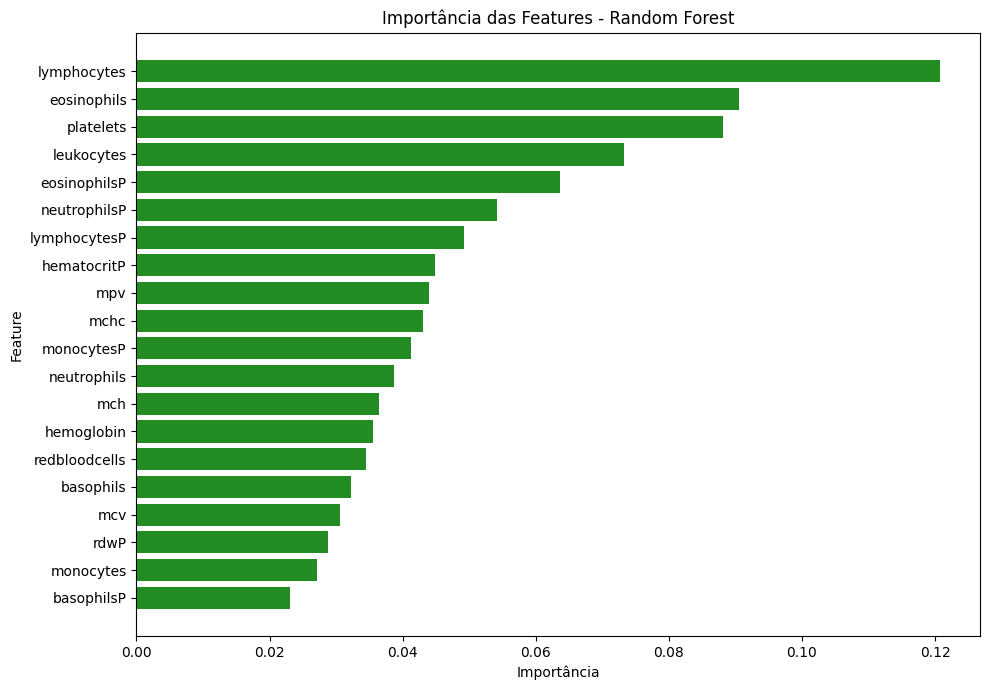

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Importância das features do Random Forest
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print('=== IMPORTÂNCIA DAS FEATURES (RANDOM FOREST) ===')
print(feature_importance.round(4).to_string(index=False))

plt.figure(figsize=(10, max(6, 0.35 * len(feature_importance))))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='forestgreen')
plt.title('Importância das Features - Random Forest')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

=== MÉTRICAS DE DESEMPENHO ===

Acurácia: 0.7928
Precisão: 0.7706
Recall:   0.7383
F1-Score: 0.7498
MCC:      0.5079
AUC:      0.8622
--------------------------------------------------


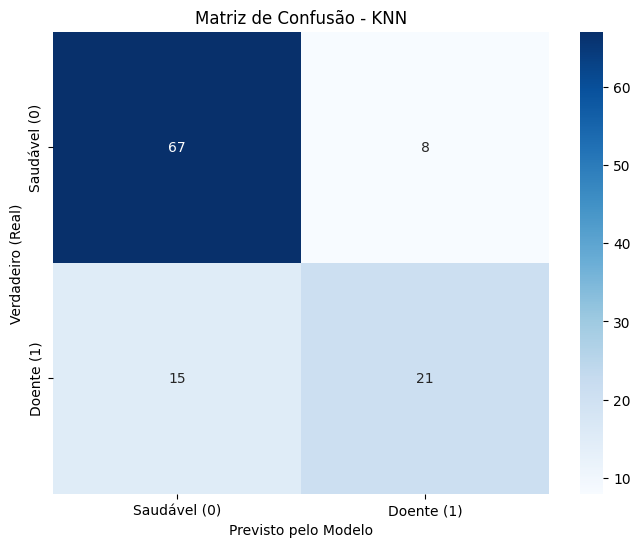

In [19]:
# Fazendo as Previsões
y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

# Métricas
acuracia_best = accuracy_score(y_test, y_pred_best)
precisao_best = precision_score(y_test, y_pred_best, average='macro')
recall_best   = recall_score(y_test, y_pred_best, average='macro')
f1_best       = f1_score(y_test, y_pred_best, average='macro')
mcc_best      = matthews_corrcoef(y_test, y_pred_best)

# O AUC binário recebe as classes reais e as probabilidades diretamente
auc = roc_auc_score(y_test, y_prob_best)

# Exibindo os Resultados
print("=== MÉTRICAS DE DESEMPENHO ===\n")
print(f"Acurácia: {acuracia_best:.4f}")
print(f"Precisão: {precisao_best:.4f}")
print(f"Recall:   {recall_best:.4f}")
print(f"F1-Score: {f1_best:.4f}")
print(f"MCC:      {mcc_best:.4f}")
print(f"AUC:      {auc:.4f}")
print("-" * 50)


# 5. Plotando a Matriz de Confusão
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)

# Labels ajustados exclusivamente para as duas doenças
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Saudável (0)', 'Doente (1)'],
            yticklabels=['Saudável (0)', 'Doente (1)'])

plt.title('Matriz de Confusão - KNN')
plt.xlabel('Previsto pelo Modelo')
plt.ylabel('Verdadeiro (Real)')
plt.show()

## Salvar Resultados

In [18]:
import os
import pandas as pd

nome_modelo = 'rf'

# Caminhos dos arquivos
pasta_results = os.path.join(caminho, 'results')
os.makedirs(pasta_results, exist_ok=True)

arquivo_pred = os.path.join(pasta_results, 'predicoes.csv')
arquivo_proba = os.path.join(pasta_results, 'probabilidades.csv')

# Monta a linha com as predições de teste
linha_pred_teste = [nome_modelo, 'teste'] + list(y_pred_best)

# Salva adicionando no final do arquivo (mode='a')
pd.DataFrame([linha_pred_teste]).to_csv(
    arquivo_pred, mode='a', header=False, index=False
)

# Monta a linha com as probabilidades de teste 
probs = (
    y_prob_best[:, 1]
    if hasattr(y_prob_best, 'ndim') and y_prob_best.ndim == 2
    else y_prob_best
)
linha_proba_teste = [nome_modelo, 'teste'] + list(probs)

pd.DataFrame([linha_proba_teste]).to_csv(
    arquivo_proba, mode='a', header=False, index=False
)

print(f'Predições e probabilidades do modelo {nome_modelo} salvas com sucesso!')

Predições e probabilidades do modelo rf salvas com sucesso!
